
# Class 23: Differential Equations and Numerical Methods
### Computational Methods for Classical Mechanics with Python

This notebook accompanies **Class 23**, where we introduce ordinary differential equations (ODEs), derive simple numerical methods on the board, and then implement them in Python.

## Goals
By the end of this notebook, you should be able to:
1. understand what an ODE is,
2. see how an initial value problem is defined,
3. implement Euler's method,
4. implement the midpoint method,
5. compare numerical and exact solutions,
6. explore the effect of step size,
7. implement Heun's method on your own.



## 1. What is an ordinary differential equation?

A first-order ODE has the form

$$
\frac{dy}{dt} = f(t,y).
$$

To determine a unique solution, we also need an initial condition, such as

$$
y(t_0) = y_0.
$$

Together, these form an **initial value problem**.

In this class, we will focus on a simple example with a known exact solution:

$$
\frac{dy}{dt} = -k y, \qquad y(0) = y_0.
$$

The exact solution is

$$
y(t) = y_0 e^{-kt}.
$$

This makes it easy to compare numerical methods against the true answer.


In [1]:

import numpy as np
import matplotlib.pyplot as plt



## 2. The model problem: exponential decay

We define the right-hand side function

$$
f(t,y) = -k y.
$$

Then we choose:
- a decay constant `k`,
- an initial value `y0`,
- a time interval,
- and a step size `h`.


In [22]:

# Parameters for the problem
k = 1.0
y0 = 1.0
t0 = 0.0
tf = 5.0
omega = 1.0


In [23]:

def f(t, y):
    # return -k*y
    return np.cos(omega*t)

def exact_solution(t):
    # return y0 * np.exp(-k*t)
    return y0 + np.sin(omega*t)/omega



## 3. Euler's method

For the ODE

$$
\frac{dy}{dt} = f(t,y),
$$

Euler's method updates the solution by

$$
y_{n+1} = y_n + h f(t_n, y_n).
$$

This is the simplest numerical method. It uses the slope at the current point to step forward.


In [24]:

def euler_method(f, t0, tf, y0, h):
    t = np.arange(t0, tf+h, h)
    y = np.zeros_like(t)
    y[0] = y0

    for n in range(len(t) - 1):
        y[n+1] = y[n] + h*f(t[n],y[n])

    return t, y


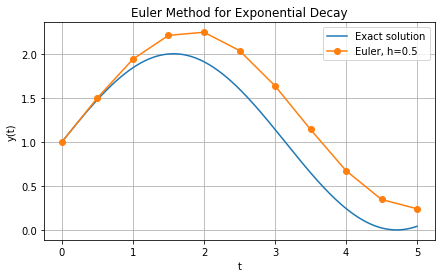

In [25]:

# Try Euler's method
h = 0.5
t_euler, y_euler = euler_method(f, t0, tf, y0, h)

t_exact = np.linspace(t0, tf, 400)
y_exact = exact_solution(t_exact)

plt.figure(figsize=(7, 4))
plt.plot(t_exact, y_exact, label="Exact solution")
plt.plot(t_euler, y_euler, "o-", label=f"Euler, h={h}")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Euler Method for Exponential Decay")
plt.grid(True)
plt.legend()
plt.show()



### Discussion
Notice that Euler's method follows the trend of the true solution, but it is not exact.  
Its accuracy depends strongly on the step size.



## 4. Step size study for Euler's method

A good way to understand a numerical method is to see what happens when the step size changes.


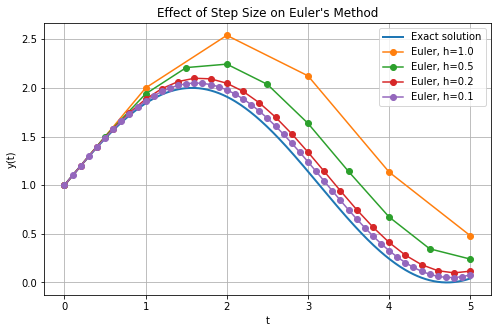

In [26]:

step_sizes = [1.0, 0.5, 0.2, 0.1]

plt.figure(figsize=(8, 5))
plt.plot(t_exact, y_exact, linewidth=2, label="Exact solution")

for h in step_sizes:
    t_num, y_num = euler_method(f, t0, tf, y0, h)
    plt.plot(t_num, y_num, "o-", label=f"Euler, h={h}")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Effect of Step Size on Euler's Method")
plt.grid(True)
plt.legend()
plt.show()



## 5. Error at the final time

We can also compare the numerical error at the final time $t_f$.


In [27]:

# for h in [1.0, 0.5, 0.2, 0.1, 0.05]:
for denom in [1.0,2.0,4.0,8.0,16.0,32.0]:
    h = 1.0/denom
    t_num, y_num = euler_method(f, t0, tf, y0, h)
    error = abs(y_num[-1] - exact_solution(t_num[-1]))
    print(f"h = {h:>4}, final-time error = {error:.6f}")


h =  1.0, final-time error = 0.439444
h =  0.5, final-time error = 0.199146
h = 0.25, final-time error = 0.094542
h = 0.125, final-time error = 0.046020
h = 0.0625, final-time error = 0.022698
h = 0.03125, final-time error = 0.011271



## 6. Midpoint method

The midpoint method improves on Euler by using slope information from the middle of the interval.

First estimate the midpoint value using Euler:

$$
y_{n+\frac12} = y_n + \frac{h}{2} f(t_n, y_n).
$$

Then update using the slope at the midpoint:

$$
y_{n+1} = y_n + h\, f\left(t_n + \frac{h}{2}, y_{n+\frac12}\right).
$$

This is a **second-order method**, so it is generally more accurate than Euler for the same step size.


In [28]:

def midpoint_method(f, t0, tf, y0, h):
    t = np.arange(t0, tf+h, h)
    y = np.zeros_like(t)
    y[0] = y0

    for n in range(len(t) - 1):
        y_mid = y[n] + 0.5*h*f(t[n],y[n])
        y[n+1] = y[n]+h*f(t[n] + 0.5*h,y_mid)
    
    return t,y


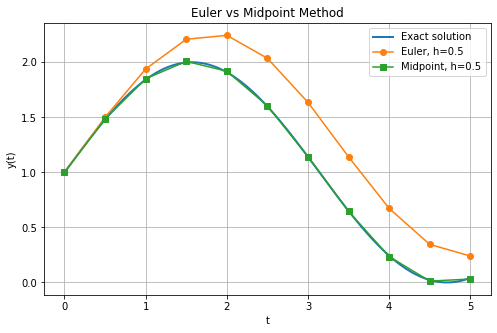

In [29]:

h = 0.5
t_mid, y_mid = midpoint_method(f, t0, tf, y0, h)

plt.figure(figsize=(8, 5))
plt.plot(t_exact, y_exact, linewidth=2, label="Exact solution")
plt.plot(t_euler, y_euler, "o-", label=f"Euler, h={h}")
plt.plot(t_mid, y_mid, "s-", label=f"Midpoint, h={h}")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Euler vs Midpoint Method")
plt.grid(True)
plt.legend()
plt.show()



## 7. Compare the errors

Let us compare final-time errors for Euler and midpoint.


In [30]:

# for h in [1.0, 0.5, 0.2, 0.1, 0.05, 0.025, 0.0125]:
for den in [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0]:
    h = 1.0 / den
    t_e, y_e = euler_method(f, t0, tf, y0, h)
    t_m, y_m = midpoint_method(f, t0, tf, y0, h)

    err_e = abs(y_e[-1] - exact_solution(t_e[-1]))
    err_m = abs(y_m[-1] - exact_solution(t_m[-1]))

    print(f"h = {h:>4} | Euler error = {err_e:.8f} | Midpoint error = {err_m:.8f}")


h =  1.0 | Euler error = 0.43944363 | Midpoint error = 0.04115206
h =  0.5 | Euler error = 0.19914578 | Midpoint error = 0.01006211
h = 0.25 | Euler error = 0.09454183 | Midpoint error = 0.00250176
h = 0.125 | Euler error = 0.04602004 | Midpoint error = 0.00062458
h = 0.0625 | Euler error = 0.02269773 | Midpoint error = 0.00015609
h = 0.03125 | Euler error = 0.01127082 | Midpoint error = 0.00003902
h = 0.015625 | Euler error = 0.00561590 | Midpoint error = 0.00000975
h = 0.0078125 | Euler error = 0.00280307 | Midpoint error = 0.00000244
h = 0.00390625 | Euler error = 0.00140032 | Midpoint error = 0.00000061



## 8. Important conceptual point

The midpoint method is **not** the same as taking two half-steps of Euler.

- In Euler's method, you always use the slope from the start of each step.
- In the midpoint method, you estimate the midpoint first, then use the slope there for the full update.

That change in where the slope is evaluated is what improves the accuracy.



## 9. Your turn: implement Heun's method

Heun's method is another second-order method, sometimes called the **improved Euler method**.

The formulas are:

1. Predictor step:
$$
\tilde{y}_{n+1} = y_n + h f(t_n, y_n)
$$

2. Corrector step:
$$
y_{n+1} = y_n + \frac{h}{2}\left[f(t_n, y_n) + f(t_{n+1}, \tilde{y}_{n+1})\right]
$$

Complete the function below.


In [11]:

def heun_method(f, t0, tf, y0, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros_like(t)
    y[0] = y0

    for n in range(len(t) - 1):
        # Step 1: predictor
        y_predict = ...

        # Step 2: corrector
        y[n + 1] = ...

    return t, y



### Check your implementation here
After completing the function above, run the next cell.


In [12]:

# Uncomment and run after implementing Heun's method

# h = 0.5
# t_heun, y_heun = heun_method(f, t0, tf, y0, h)

# plt.figure(figsize=(8, 5))
# plt.plot(t_exact, y_exact, linewidth=2, label="Exact solution")
# plt.plot(t_euler, y_euler, "o-", label=f"Euler, h={h}")
# plt.plot(t_mid, y_mid, "s-", label=f"Midpoint, h={h}")
# plt.plot(t_heun, y_heun, "d-", label=f"Heun, h={h}")
# plt.xlabel("t")
# plt.ylabel("y(t)")
# plt.title("Comparing Numerical Methods")
# plt.grid(True)
# plt.legend()
# plt.show()



## 10. Summary

In this notebook, we:
- introduced first-order ODEs,
- solved a simple decay problem numerically,
- implemented Euler's method,
- studied how step size affects the result,
- implemented the midpoint method,
- prepared a space for you to implement Heun's method.

### Preview of next class
In the next class, we will move more directly into mechanics and solve second-order differential equations, such as the harmonic oscillator, by rewriting them as systems of first-order equations.
